## The Wine dataset from Scikit-Learn is used to classify wines into three categories based on their chemical properties. Two different MLP architectures are compared using two train-test split scenarios.

### Import libraries

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

## Loading the Dataset

The Wine dataset is loaded from Scikit-Learn. It contains 178 samples with 13 numerical features representing chemical properties of wine. The target variable consists of three different wine classes.

In [6]:
wine = load_wine()

X = wine.data
y = wine.target

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (178, 13)
Target Shape : (178,)


In [7]:
print("Feature Names:\n")

print(wine.feature_names)

print("\nTarget Classes:\n")

print(wine.target_names)

Feature Names:

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Target Classes:

['class_0' 'class_1' 'class_2']


## Dataset Overview

Let's observe the first few records of the dataset.

In [8]:
import pandas as pd

df = pd.DataFrame(X, columns=wine.feature_names)

df["Target"] = y

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Scenario 1

### Training Data : 70%

### Testing Data : 30%

In [9]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

## Feature Scaling

Neural networks perform better when all input features are on a similar scale. Therefore, StandardScaler is applied before training the MLP models.

In [10]:
scaler1 = StandardScaler()

X_train1 = scaler1.fit_transform(X_train1)

X_test1 = scaler1.transform(X_test1)

## MLP Model 1

Architecture

- Hidden Layers : (100,100)

- Activation : ReLU

- Optimizer : Adam

- Maximum Iterations : 2000

In [11]:
mlp1 = MLPClassifier(
    hidden_layer_sizes=(100,100),
    max_iter=2000,
    learning_rate_init=0.001,
    random_state=42
)

mlp1.fit(X_train1, y_train1)

,hidden_layer_sizes,"(100, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,2000
,shuffle,True
,random_state,42


## Prediction

In [12]:
y_pred1 = mlp1.predict(X_test1)

## Model Evaluation

In [13]:
accuracy = accuracy_score(y_test1, y_pred1)

precision = precision_score(
    y_test1,
    y_pred1,
    average="weighted"
)

recall = recall_score(
    y_test1,
    y_pred1,
    average="weighted"
)

f1 = f1_score(
    y_test1,
    y_pred1,
    average="weighted"
)

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 Score :", f1)

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0


Classification report

In [14]:
print(classification_report(y_test1, y_pred1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



Confusion Matrix

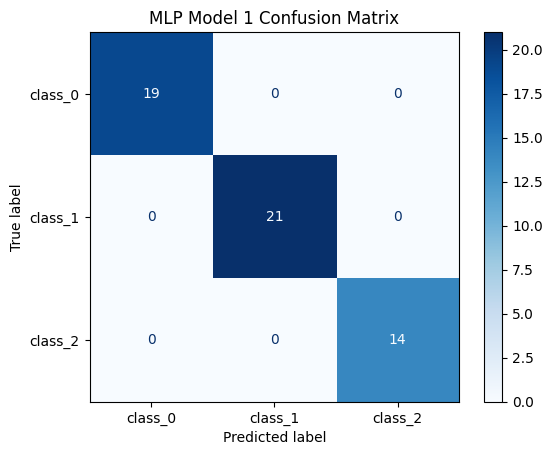

In [15]:
cm = confusion_matrix(y_test1, y_pred1)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=wine.target_names
)

disp.plot(cmap="Blues")

plt.title("MLP Model 1 Confusion Matrix")

plt.show()

Loss Curve

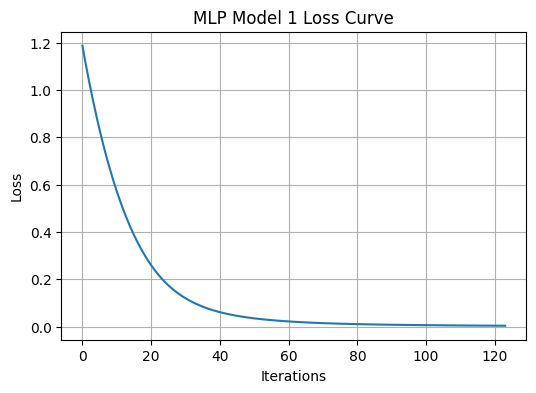

In [16]:
plt.figure(figsize=(6,4))

plt.plot(mlp1.loss_curve_)

plt.title("MLP Model 1 Loss Curve")

plt.xlabel("Iterations")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

## MLP Model 2

The second MLP model is designed with a simpler architecture consisting of a single hidden layer containing 50 neurons. This model is expected to learn the patterns efficiently while reducing the complexity of the network.

In [17]:
mlp2 = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=2000,
    learning_rate_init=0.001,
    random_state=42
)

mlp2.fit(X_train1, y_train1)

,hidden_layer_sizes,"(50,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,2000
,shuffle,True
,random_state,42


## Prediction using MLP Model 2

The trained model is now used to predict the class labels of the testing dataset.

In [18]:
y_pred2 = mlp2.predict(X_test1)

## Performance Evaluation

The model performance is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score

In [19]:
accuracy2 = accuracy_score(y_test1, y_pred2)

precision2 = precision_score(
    y_test1,
    y_pred2,
    average="weighted"
)

recall2 = recall_score(
    y_test1,
    y_pred2,
    average="weighted"
)

f1_2 = f1_score(
    y_test1,
    y_pred2,
    average="weighted"
)

print(f"Accuracy  : {accuracy2:.4f}")
print(f"Precision : {precision2:.4f}")
print(f"Recall    : {recall2:.4f}")
print(f"F1 Score  : {f1_2:.4f}")

Accuracy  : 0.9815
Precision : 0.9827
Recall    : 0.9815
F1 Score  : 0.9816


Classification Report

In [20]:
print(classification_report(y_test1, y_pred2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.95      0.98        21
           2       0.93      1.00      0.97        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



Confusion Matrix

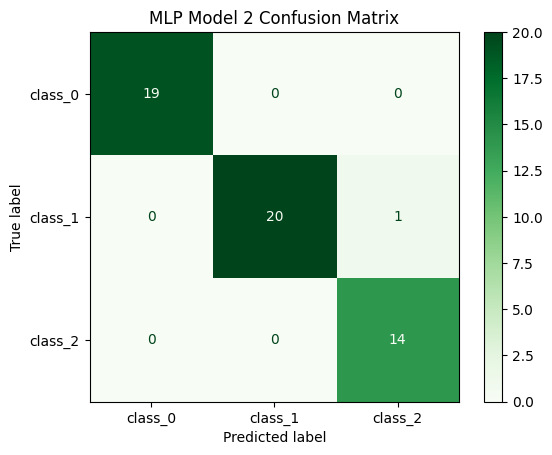

In [21]:
cm2 = confusion_matrix(y_test1, y_pred2)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm2,
    display_labels=wine.target_names
)

disp.plot(cmap="Greens")

plt.title("MLP Model 2 Confusion Matrix")

plt.show()

Loss Curve

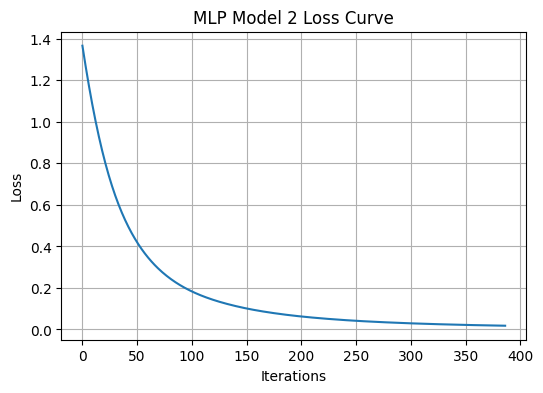

In [22]:
plt.figure(figsize=(6,4))

plt.plot(mlp2.loss_curve_)

plt.title("MLP Model 2 Loss Curve")

plt.xlabel("Iterations")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

## Comparison of MLP Models (Scenario 1)

The evaluation metrics of both MLP models are compared to identify which architecture performs better on the Wine dataset.

In [23]:
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "MLP Model 1": [
        accuracy,
        precision,
        recall,
        f1
    ],
    "MLP Model 2": [
        accuracy2,
        precision2,
        recall2,
        f1_2
    ]
})

comparison_df

,Metric,MLP Model 1,MLP Model 2
0,Accuracy,1.0,0.981481
1,Precision,1.0,0.982716
2,Recall,1.0,0.981481
3,F1 Score,1.0,0.981575


Bar Chart Comparison

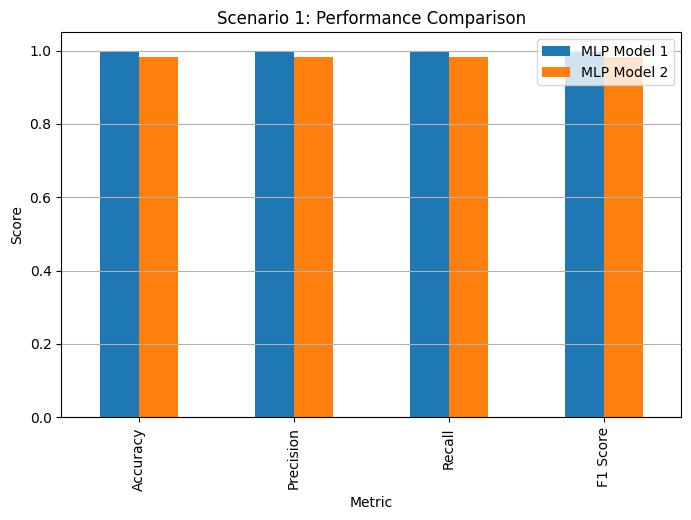

In [24]:
comparison_df.set_index("Metric").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Scenario 1: Performance Comparison")

plt.ylabel("Score")

plt.ylim(0, 1.05)

plt.grid(axis="y")

plt.show()

## Conclusion

A Multi-Layer Perceptron (MLP) classifier was successfully implemented on the Wine dataset and evaluated using Accuracy, Precision, Recall, F1 Score, and Confusion Matrix. Feature scaling using StandardScaler significantly improved the training process and model performance. Both MLP models achieved excellent classification results, with MLP Model 1 providing the highest accuracy of 100% and MLP Model 2 achieving approximately 98.15% accuracy. The results demonstrate that MLP is an effective deep learning technique for multi-class classification and that proper data preprocessing and model selection are essential for obtaining reliable and accurate predictions.